# 03 · Le mur numérique, et la question d'entretien senior

**Bloc 4 · W37, notebook 3 sur 3.**

| § | Contenu |
|---|---|
| 1 | Où ça casse n°3 : le mur `m > T` (rappel du bloc 2) |
| 2 | La question d'entretien : « MASE dégradé au SKU, amélioré au national » |
| 3 | Les trois hypothèses, chacune démontrée |
| 4 | La réponse senior : quel niveau porte la décision ? |
| 5 | ⚠️ Un point avancé : pondérer les niveaux ne change **rien** à MinT… sauf dans trois cas |
| 6 | La réponse rédigée |

> **Comment lire ce notebook.** Les encadrés suivent un code fixe :
> 💡 **Intuition**, l'idée sans les équations · 🧪 **Exemple**, une expérience chiffrée ·
> ⚠️ **Point d'attention**, le piège à éviter · 📌 **À retenir**, le mémo à garder.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from w37_reconciliation import viz
from w37_reconciliation.mint import mint_projection

viz.setup()
pd.set_option("display.precision", 3)
np.set_printoptions(precision=3, suppress=True)
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)
def export(fig, name):
    """Exporte la figure en SVG pour le README et l'article (net en mode sombre)."""
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")

## 1. Où ça casse n°3 : le mur numérique

$W_1 = E'E/T$ est de rang au plus $T$. Avec plus de séries que d'observations ($m > T$), elle est singulière :
`mint_cov` (covariance empirique pure) est inutilisable, d'où `mint_shrink`. La démonstration complète est dans le
[notebook 02 du bloc 2](../../02_mint_from_scratch/notebooks/02_covariance_et_shrinkage.ipynb).

In [2]:
from w37_reconciliation.mint import shrunk_covariance
rng = np.random.default_rng(0)
rows = []
for m, T in [(50, 156), (500, 156), (5_000, 156)]:
    E = rng.normal(size=(T, m))
    cov = shrunk_covariance(E)
    rows.append({"séries m": m, "historique T (3 ans hebdo)": T, "rang de W₁": np.linalg.matrix_rank(cov.W1),
                 "W₁ inversible ?": np.linalg.matrix_rank(cov.W1) == m, "λ shrinkage": cov.lam,
                 "cond(W shrink)": cov.condition_number})
display(pd.DataFrame(rows).style.format({"λ shrinkage": "{:.3f}", "cond(W shrink)": "{:.1f}"}))

,séries m,historique T (3 ans hebdo),rang de W₁,W₁ inversible ?,λ shrinkage,cond(W shrink)
0,50,156,50,True,1.000,1.6
1,500,156,156,False,1.000,2.3
2,5000,156,156,False,1.000,2.3


> 📌 **À retenir — corollaire de mission.** Avant de chiffrer, demander **le nombre de séries et la profondeur
> d'historique**, dans cet ordre. Avec 40 000 SKU et 3 ans d'hebdomadaire, $m/T \approx 250$ : le shrinkage n'est
> pas une option.

## 2. La question

> **« Vous réconciliez avec MinT et votre MASE se dégrade au niveau SKU alors qu'il s'améliore au niveau national.
> Que se passe-t-il, et que faites-vous ? »**

Trois hypothèses, **dans cet ordre** : de la plus fréquente et la moins chère à vérifier, à la plus subtile.

## 3. Les trois hypothèses, démontrées

### Hypothèse 1 — une prévision de base est biaisée

C'est le notebook 01 : MinT suppose des prévisions de base non biaisées. Le symptôme est exactement celui de la
question. **Test** : moyenne des résidus par niveau (`residual_bias_table`). **Remède** : débiaiser *avant* de
réconcilier.

🧪 Résidus in-sample sur 52 semaines : le total est sous-prévu de 1,5 en moyenne (modèle national trop rigide
face aux promotions), les feuilles sont propres.


In [3]:
from w37_reconciliation.fundamentals import toy_hierarchy
S = toy_hierarchy(); names = ["Total", "Feuille_1", "Feuille_2", "Feuille_3"]
from w37_reconciliation.fundamentals.diagnostics import residual_bias_table
E_res = np.random.default_rng(4).normal(size=(52, 4)) * [1.0, 3.0, 3.0, 3.0] + [1.5, 0, 0, 0]
display(residual_bias_table(E_res, names).style.format({"moyenne": "{:+.2f}", "écart-type": "{:.2f}", "t": "{:+.2f}"}))

,moyenne,écart-type,t,biais suspect
Total,+1.46,1.17,+9.00,True
Feuille_1,+0.12,2.98,+0.30,False
Feuille_2,-0.00,2.79,-0.01,False
Feuille_3,+0.49,2.86,+1.24,False


> ⚠️ **Point d'attention.** Le test porte sur les résidus **de base**, pas sur les résidus réconciliés : après MinT,
> le biais du total est déjà dilué dans les feuilles et le diagnostic devient flou.

### Hypothèse 2 — $W$ est mal estimée

Si $W$ **sous-estime** la variance d'erreur des agrégats, MinT leur fait trop confiance, et leurs erreurs sont
redistribuées vers les feuilles.

🧪 Le total a en réalité une erreur d'écart-type 3, comme chaque feuille, mais $W$ le croit à 1. Sans aucun biais.

In [4]:
from w37_reconciliation.fundamentals import toy_hierarchy
S = toy_hierarchy(); names = ["Total", "Feuille_1", "Feuille_2", "Feuille_3"]
sd_true = np.array([3.0, 3.0, 3.0, 3.0])
err = np.random.default_rng(3).normal(size=(50_000, 4)) * sd_true
P_bu = S @ np.hstack([np.zeros((3, 1)), np.eye(3)])
cands = {"bottom-up": P_bu,
         "MinT, W correcte": mint_projection(S, np.diag(sd_true**2))[1],
         "MinT, W sous-estime le total": mint_projection(S, np.diag([1.0, 9, 9, 9]))[1],
         "OLS (W = I)": mint_projection(S, np.eye(4))[1]}
tab = pd.DataFrame({k: {"MAE total": np.abs(err @ P.T)[:, 0].mean(), "MAE feuilles": np.abs(err @ P.T)[:, 1:].mean()}
                    for k, P in cands.items()}).T
display(tab.style.format("{:.3f}"))

,MAE total,MAE feuilles
bottom-up,4.131,2.392
"MinT, W correcte",2.071,2.073
"MinT, W sous-estime le total",2.312,2.101
OLS (W = I),2.071,2.073


Avec un $W$ faux, MinT perd en partie son avantage sur les feuilles. **Test** : comparer `ols`, `wls_struct` et
`mint_shrink` en backtest **par niveau**, et regarder la **stabilité de λ** d'une fenêtre à l'autre. Un λ qui saute
signale une covariance mal estimée.

### Hypothèse 3 — fuite ou fenêtre inadaptée

Les résidus qui servent à estimer $W$ couvrent un **changement de régime** : refonte du référentiel produit,
changement de gamme, Covid. $W$ décrit alors un monde qui n'existe plus.

| Vérification | Comment |
|---|---|
| La fenêtre de $W$ est-elle strictement antérieure à l'origine ? | assertion `Y_fit.ds.max() < test.ds.min()` (bloc 2) |
| Un événement de référentiel tombe-t-il dans la fenêtre ? | journal des versions de `dim_produit` + `hash_check` (bloc 3) |
| $W$ est-elle stable ? | estimer $W$ sur deux sous-fenêtres et comparer λ, les variances et les corrélations |

## 4. La réponse senior : quel niveau porte la décision ?

Le vrai arbitrage n'est pas statistique, il est **métier**. Si l'approvisionnement se décide au SKU, une
amélioration au national qui coûte au SKU est une **régression**. On voudrait alors pondérer l'objectif par niveau,
$\operatorname{tr}(\Lambda \, S G W G' S')$, plutôt que minimiser une trace uniforme. C'est le λᵢ du papier
2606.23009 (bloc 1) et le `level_weights` du contrat (bloc 3).

## 5. ⚠️ Point avancé : pondérer les niveaux ne change rien à MinT… si $W$ est juste et sans biais

Le **théorème de Gauss-Markov** dit plus fort que « MinT minimise la trace » : pour **toute** autre réconciliation
non biaisée $G$,

$$S G^* W G^{*\prime} S' \;\preceq\; S G W G' S' \qquad (\text{ordre de Loewner : la différence est semi-définie positive})$$

Autrement dit, MinT minimise **simultanément** la variance d'erreur de **chaque** série. Toute pondération
$\Lambda \succeq 0$ des niveaux a donc le même optimum : MinT.

🧪 **Vérification numérique** : on tire 2 000 réconciliations non biaisées au hasard ($G = G^* + K$, avec $KS = 0$),
et on compare leur score pondéré à celui de MinT, pour quatre pondérations très différentes.

In [5]:
from w37_reconciliation.fundamentals.diagnostics import weighted_trace_check, random_unbiased_G
A = np.random.default_rng(1).normal(size=(4, 4)); W = A @ A.T + np.eye(4)
weights = {"uniforme": [1, 1, 1, 1], "national ×10": [10, 1, 1, 1], "tout sur le national": [1, 1e-3, 1e-3, 1e-3],
           "tout sur la feuille 1": [1e-3, 1, 1e-3, 1e-3]}
res = pd.DataFrame({k: weighted_trace_check(S, W, np.array(v, float)) for k, v in weights.items()}).T
display(res.style.format({"score MinT": "{:.4f}", "meilleur score aléatoire": "{:.4f}",
                          "part des G aléatoires battant MinT": "{:.1%}"}))

,score MinT,meilleur score aléatoire,part des G aléatoires battant MinT
uniforme,5.8629,5.8680,0.0%
national ×10,20.0191,20.0255,0.0%
tout sur le national,1.5772,1.5772,0.0%
tout sur la feuille 1,1.8188,1.8188,0.0%


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


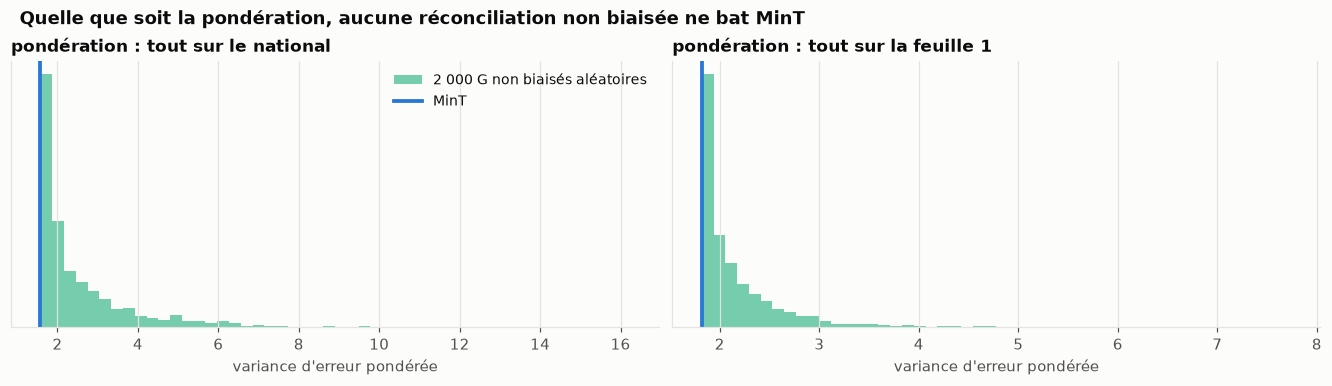

In [6]:
rng = np.random.default_rng(2); G_star, _ = mint_projection(S, W)
fig, axs = plt.subplots(1, 2, figsize=(12, 3.4), layout="constrained")
for ax, (label, lw) in zip(axs, [("pondération : tout sur le national", [1, 1e-3, 1e-3, 1e-3]),
                                 ("pondération : tout sur la feuille 1", [1e-3, 1, 1e-3, 1e-3])]):
    Lam = np.diag(lw)
    sc = lambda G: np.trace(Lam @ S @ G @ W @ G.T @ S.T)
    scores = [sc(random_unbiased_G(S, G_star, rng)) for _ in range(2_000)]
    ax.hist(scores, bins=50, color=viz.AQUA, alpha=0.6, edgecolor="none", label="2 000 G non biaisés aléatoires")
    ax.axvline(sc(G_star), color=viz.BLUE, lw=2.5, label="MinT")
    ax.set_title(label); ax.set_xlabel("variance d'erreur pondérée"); ax.set_yticks([]); ax.grid(axis="y", visible=False)
axs[0].legend(loc="upper right", fontsize=9)
fig.suptitle("Quelle que soit la pondération, aucune réconciliation non biaisée ne bat MinT", x=0.01, ha="left",
             fontweight="semibold")
export(fig, "gauss_markov"); plt.show()

**Donc, quand la pondération par niveau sert-elle ?** Dans les trois situations où les hypothèses de Gauss-Markov
tombent, c'est-à-dire précisément les trois hypothèses du § 3 :

1. **Il y a un biais.** L'erreur quadratique vaut alors variance + biais², et le meilleur compromis dépend du niveau
   (exemple ci-dessous).
2. **$W$ est estimée, donc fausse.** On choisit entre plusieurs estimateurs (`ols`, `wls_struct`, `mint_shrink`) par
   backtest, et ce choix se fait avec des poids par niveau.
3. **On relâche la contrainte de non-biais ou de cohérence exacte.** C'est le cas de la cohérence *souple* de
   2606.23009 : le λᵢ y a un vrai effet.

🧪 **Exemple du cas 1** : le scénario du notebook 01 (total précis mais biaisé, feuilles bruitées), avec un biais
croissant. Pour chaque biais, quelle méthode gagne **au total**, et laquelle gagne **aux feuilles** ?

In [7]:
from w37_reconciliation.fundamentals import bias_sweep
sweep = bias_sweep(np.arange(0, 8.5, 0.5)).query("méthode != 'base'")
mae = sweep.pivot(index="biais", columns="méthode", values=["MAE total", "MAE feuilles"])
choix = pd.DataFrame({
    "MAE total BU / MinT": mae["MAE total"].apply(lambda r: f"{r['bottom-up']:.2f} / {r['MinT']:.2f}", axis=1),
    "gagnant au total": mae["MAE total"].idxmin(axis=1),
    "MAE feuilles BU / MinT": mae["MAE feuilles"].apply(lambda r: f"{r['bottom-up']:.2f} / {r['MinT']:.2f}", axis=1),
    "gagnant aux feuilles": mae["MAE feuilles"].idxmin(axis=1),
})
desaccord = choix["gagnant au total"] != choix["gagnant aux feuilles"]
display(choix.style.apply(lambda r: ["background-color: rgba(250, 180, 60, .25)" if desaccord[r.name] else ""] * len(r),
                          axis=1))
print(f"Zone où le choix dépend du niveau de décision : biais ∈ {choix.index[desaccord].min()} … {choix.index[desaccord].max()}")

,MAE total BU / MinT,gagnant au total,MAE feuilles BU / MinT,gagnant aux feuilles
biais,,,,
0.000000,4.13 / 0.79,MinT,2.39 / 1.97,MinT
0.500000,4.13 / 0.88,MinT,2.39 / 1.97,MinT
1.000000,4.13 / 1.13,MinT,2.39 / 1.98,MinT
1.500000,4.13 / 1.51,MinT,2.39 / 2.00,MinT
2.000000,4.13 / 1.95,MinT,2.39 / 2.03,MinT
2.500000,4.13 / 2.42,MinT,2.39 / 2.07,MinT
3.000000,4.13 / 2.89,MinT,2.39 / 2.12,MinT
3.500000,4.13 / 3.38,MinT,2.39 / 2.17,MinT
4.000000,4.13 / 3.86,MinT,2.39 / 2.23,MinT


Zone où le choix dépend du niveau de décision : biais ∈ 4.5 … 5.0


Trois régimes se lisent dans le tableau :

- **biais faible** : MinT gagne aux deux niveaux, et la pondération ne change rien ;
- **biais fort** : le bottom-up gagne aux deux niveaux, et la pondération ne change rien non plus ;
- **entre les deux** (lignes surlignées) : MinT gagne aux feuilles et perd au total. Le choix **dépend** du niveau
  qui porte la décision. C'est là, et seulement là, que `level_weights` change quelque chose.

> ⚠️ **Point d'attention — pondérer des MAE bruts.** Les MAE du total (≈ 4) et des feuilles (≈ 2,4) ne sont pas à la
> même échelle. Un score `0,1 × MAE total + 0,9 × MAE feuilles` reste dominé par le total, et donne bottom-up même
> quand la décision se prend à la feuille. Pondérez des erreurs **mises à l'échelle** (MASE, ou MAE relatif à la
> base), jamais des MAE bruts entre niveaux.

> 📌 **À retenir — pondérer les niveaux.**
> - Avec la vraie $W$ et sans biais, MinT est optimal **pour tous les niveaux à la fois** (Gauss-Markov) : les poids
>   n'y changent rien.
> - Les poids servent à **arbitrer quand les hypothèses tombent** : biais, $W$ estimée, cohérence souple.
> - Dans le contrat du bloc 3, `level_weights` sert donc à **choisir entre méthodes** en backtest. Il ne modifie pas
>   la formule de MinT.

## 6. La réponse rédigée

> **Q.** *« Vous réconciliez avec MinT et votre MASE se dégrade au niveau SKU alors qu'il s'améliore au niveau
> national. Que se passe-t-il, et que faites-vous ? »*
>
> **R.** « MinT est optimal sous deux hypothèses : des prévisions de base non biaisées, et une covariance d'erreur
> $W$ correcte. Le symptôme décrit indique qu'au moins l'une des deux tombe. Je vérifie dans cet ordre :
>
> 1. **Un biais de base.** Je teste la moyenne des résidus in-sample, niveau par niveau. Un national lissé par un
>    modèle rigide, alors que les SKU portent les promotions, est le cas typique. MinT répartit ce biais sur tous
>    les SKU, en proportion de la confiance que $W$ accorde au national. Je débiaise **avant** de réconcilier.
> 2. **Une $W$ mal estimée.** Si elle sous-estime la variance des agrégats, MinT leur fait trop confiance. Je
>    compare `ols`, `wls_struct` et `mint_shrink` en backtest par niveau, et je regarde la stabilité de λ.
> 3. **Une fuite ou une fenêtre inadaptée.** Des résidus qui couvrent un changement de référentiel ou de gamme, ou
>    une fenêtre qui touche la période de test.
>
> Ensuite, la vraie question est métier : **quel niveau porte la décision ?** Si l'appro se fait au SKU, une
> amélioration au national payée au SKU est une régression. Je choisis alors la méthode, en backtest, sur un score
> pondéré par niveau, avec un quality gate qui bloque toute dégradation au niveau de décision. Je précise que,
> sans biais et avec une bonne $W$, MinT est optimal à tous les niveaux à la fois : la pondération ne sert qu'à
> arbitrer quand ces hypothèses tombent.
>
> Enfin, si la décision porte sur un **niveau de service** (un quantile), MinT n'en dit rien : il faut réconcilier
> des **échantillons joints**, obtenus par bootstrap des résidus aux mêmes instants. Sinon, l'intervalle à 90 %
> annoncé au national couvre en réalité 76 %. »